# Урок 15.5. Производная

**Интерактивная версия:** `lessons/lesson_15_5/web/index.html` — там те же опыты на живых графиках.

**После урока вы сможете:** находить производную по определению и читать её обозначения с единицами;
объяснять три её смысла — наклон касательной, скорость, линейное приближение — и составлять уравнение
касательной; узнавать точки без производной и пользоваться субградиентом; по знаку $f'$ находить рост,
экстремумы и наибольшее значение на отрезке, применять теорему Лагранжа; считать производные численно,
выбирая шаг с учётом округления и шума; выводить псевдо-остатки функций потерь.

Блоки урока:

1. **Определение:** приращения, предел разностного отношения, обозначения, вычисление по определению, $f'$ как функция.
2. **Три смысла:** *производная — это наклон* (секущая → касательная), касательная и нормаль, скорость, линейное приближение.
3. **Когда производной нет:** односторонние производные, галерея «плохих» точек, гладкость, субградиент.
4. **Что производная говорит о функции:** монотонность, экстремумы и теорема Ферма, теорема Лагранжа.
5. **Как считать:** линейность, обратная функция, численная производная, шумные данные.
6. **В ML:** градиентный спуск и темп, производные потерь, лучшая константа, псевдо-остатки и деревья.

In [1]:
import sys
from pathlib import Path

ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "shared" / "python" / "gbcourse").is_dir())
sys.path.insert(0, str(ROOT / "shared" / "python"))

import matplotlib.pyplot as plt
import numpy as np
from IPython.display import HTML, display
from matplotlib import animation
from scipy import optimize

from gbcourse import datasets
from gbcourse.boosting import GBRegressor
from gbcourse.plotting import use_course_style
from gbcourse.rng import Mulberry32
from gbcourse.style import AQUA, BLUE, MUTED, ORANGE, RED, VIOLET
from gbcourse.tree import RegressionTree

use_course_style()
plt.rcParams["animation.embed_limit"] = 30  # МБ: анимации встраиваются в ноутбук


def quotient(f, a, h):
    """Разностное отношение (f(a + h) − f(a)) / h."""
    return (f(a + h) - f(a)) / h


def central(f, a, h=1e-5):
    """Центральная разность — численная производная."""
    return (f(a + h) - f(a - h)) / (2 * h)

## Блок 1. Определение

### 1. Приращения и разностное отношение

Сдвиг аргумента $\Delta x$ даёт приращение функции $\Delta f = f(a + \Delta x) - f(a)$, а отношение
$\frac{\Delta f}{\Delta x}$ — среднюю скорость изменения $f$ на отрезке, наклон секущей.

In [2]:
f = lambda x: x**2  # noqa: E731
for dx in [0.5, -0.5, 0.1, -0.1]:
    df = f(1 + dx) - f(1)
    print(f"x² в точке 1, Δx = {dx:5}: Δf = {df: .4f}, Δf/Δx = {df / dx:.4f}")
print("sin на [0, 2π]: отношение =", round(quotient(np.sin, 0, 2 * np.pi), 12), "— средняя скорость ничего не знает о том, что между точками")

x² в точке 1, Δx =   0.5: Δf =  1.2500, Δf/Δx = 2.5000
x² в точке 1, Δx =  -0.5: Δf = -0.7500, Δf/Δx = 1.5000
x² в точке 1, Δx =   0.1: Δf =  0.2100, Δf/Δx = 2.1000
x² в точке 1, Δx =  -0.1: Δf = -0.1900, Δf/Δx = 1.9000
sin на [0, 2π]: отношение = -0.0 — средняя скорость ничего не знает о том, что между точками


### 2. Производная — предел разностного отношения

$$f'(a) = \lim_{h \to 0}\frac{f(a + h) - f(a)}{h}.$$

Как функция шага, $q(h)$ определена при $h \ne 0$, а в нуле у графика дырка; производная её «заклеивает».
Предел должен совпадать с обеих сторон.

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


√x в точке 4: [0.267949 0.251582 0.250156 0.250016 0.249984 0.249844 0.248457 0.236068]
|x| в точке 0: [-1. -1. -1. -1.  1.  1.  1.  1.] — справа 1, слева −1: производной нет


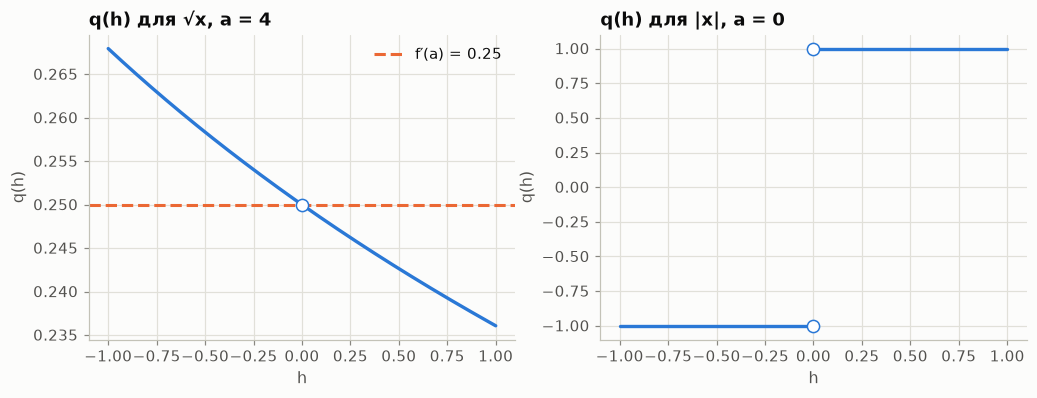

In [3]:
hs = np.array([-1, -0.1, -0.01, -0.001, 0.001, 0.01, 0.1, 1])
print("√x в точке 4:", np.round(quotient(np.sqrt, 4, hs), 6))
print("|x| в точке 0:", quotient(np.abs, 0, hs), "— справа 1, слева −1: производной нет")

h = np.linspace(-1, 1, 801)
h = h[np.abs(h) > 1e-9]
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, (name, g, a, L) in zip(axes, [("√x, a = 4", np.sqrt, 4, 0.25), ("|x|, a = 0", np.abs, 0, None)]):
    q = quotient(g, a, h)
    ax.plot(h[h < 0], q[h < 0], color=BLUE, lw=2.2)
    ax.plot(h[h > 0], q[h > 0], color=BLUE, lw=2.2)
    if L is not None:
        ax.axhline(L, color=ORANGE, ls="--", label=f"f′(a) = {L}")
        ax.plot([0], [L], "o", mfc="white", mec=BLUE, ms=8)
        ax.legend()
    else:
        ax.plot([0, 0], [1, -1], "o", mfc="white", mec=BLUE, ms=8)
    ax.set(title=f"q(h) для {name}", xlabel="h", ylabel="q(h)")
plt.show()

### 3. Обозначения и единицы

$f'(x)$ (Лагранж), $\frac{df}{dx}$ (Лейбниц), $\dot s$ (Ньютон), $\frac{\partial L}{\partial F}$ — производная по одной
переменной при фиксированных остальных. Единица производной — [f] / [x]: м/с, ₽ за штуку, «потери на 1 млн прогноза».

### 4. Производная по определению

Алгоритм: приращение → отношение → сократить $h$ → предел. Результаты (выкладки — на странице урока):
$(x^2)' = 2x$, $(x^3)' = 3x^2$, $(\frac1x)' = -\frac1{x^2}$, $(\sqrt x)' = \frac1{2\sqrt x}$, $(e^x)' = e^x$,
$(\sin x)' = \cos x$, $\frac{\partial}{\partial F}\frac12(y - F)^2 = -(y - F)$. Проверим каждую таблицей.

In [4]:
table = {
    "x²": (lambda x: x**2, lambda x: 2 * x),
    "x³": (lambda x: x**3, lambda x: 3 * x**2),
    "1/x": (lambda x: 1 / x, lambda x: -1 / x**2),
    "√x": (np.sqrt, lambda x: 1 / (2 * np.sqrt(x))),
    "eˣ": (np.exp, np.exp),
    "sin x": (np.sin, np.cos),
}
for name, (g, dg) in table.items():
    x0 = 1.3
    qs = [quotient(g, x0, h) for h in (0.1, 0.01, 0.001)]
    print(f"{name:6} в x = {x0}: отношения {np.round(qs, 6)} → формула {dg(x0):.6f}")

y_, F_ = 5.0, 2.0
L = lambda F: 0.5 * (y_ - F) ** 2  # noqa: E731
print("½(y − F)² при y = 5, F = 2: численно", round(central(L, F_), 8), "формула −(y − F) =", -(y_ - F_))

x²     в x = 1.3: отношения [2.7   2.61  2.601] → формула 2.600000
x³     в x = 1.3: отношения [5.47     5.1091   5.073901] → формула 5.070000
1/x    в x = 1.3: отношения [-0.549451 -0.587199 -0.591261] → формула -0.591716
√x     в x = 1.3: отношения [0.430405 0.437689 0.438445] → формула 0.438529
eˣ     в x = 1.3: отношения [3.859033 3.687704 3.671132] → формула 3.669297
sin x  в x = 1.3: отношения [0.218915 0.262677 0.267017] → формула 0.267499
½(y − F)² при y = 5, F = 2: численно -3.0 формула −(y − F) = -3.0


### 5. Производная — тоже функция

Собрав наклоны во всех точках, получаем новую функцию $x \mapsto f'(x)$. Её область может быть меньше:
у $\sqrt x$ нет производной в нуле, у $|x|$ — в нуле.

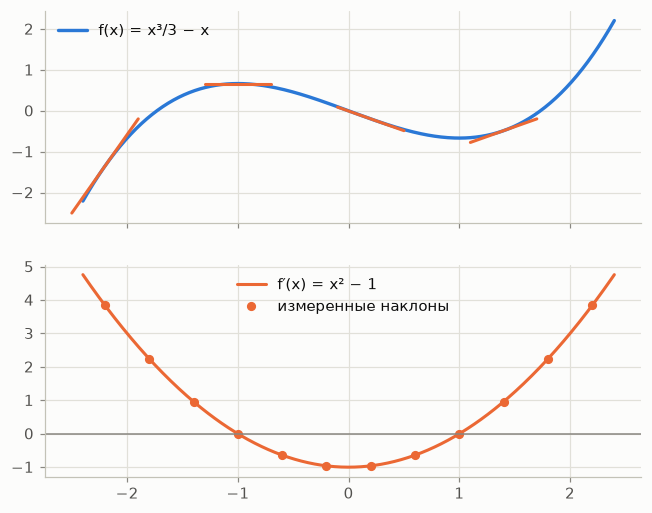

In [5]:
x = np.linspace(-2.4, 2.4, 400)
g = lambda x: x**3 / 3 - x  # noqa: E731
xs = np.linspace(-2.2, 2.2, 12)
fig, (a1, a2) = plt.subplots(2, 1, figsize=(7, 5.5), sharex=True)
a1.plot(x, g(x), color=BLUE, lw=2.2, label="f(x) = x³/3 − x")
for x0 in xs[::3]:
    k = central(g, x0)
    a1.plot([x0 - 0.3, x0 + 0.3], [g(x0) - 0.3 * k, g(x0) + 0.3 * k], color=ORANGE, lw=2)
a1.legend()
a2.plot(x, x**2 - 1, color=ORANGE, lw=2, label="f′(x) = x² − 1")
a2.plot(xs, central(g, xs), "o", color=ORANGE, label="измеренные наклоны")
a2.axhline(0, color=MUTED, lw=1)
a2.legend()
plt.show()

## Блок 2. Три смысла производной

### 6. Производная — это наклон

Наклон прямой — подъём/пробег $= \operatorname{tg}\alpha$. Наклон секущей через $a$ и $a + h$ — разностное
отношение. При $h \to 0$ секущая поворачивается вокруг точки и в пределе становится **касательной**;
её наклон — производная. Анимация: $f(x) = \frac{x^3}{3} - x$, $a = 0.5$, $f'(0.5) = -0.75$.

In [6]:
a = 0.5
hs = 2 * 10 ** (-3 * np.arange(41) / 40)
grid = np.linspace(-2.6, 2.6, 400)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 4))
a1.plot(grid, g(grid), color=BLUE, lw=2.2, label="f(x)")
a1.plot(grid, g(a) - 0.75 * (grid - a), "--", color=ORANGE, label="касательная")
(sec,) = a1.plot([], [], color=AQUA, lw=2, label="секущая")
(pts,) = a1.plot([], [], "o", color=AQUA)
a1.set(ylim=(-2.5, 2.5), xlabel="x", ylabel="f(x)")
a1.legend(loc="upper left")
a2.semilogx(hs, quotient(g, a, hs), color=AQUA, lw=2, label="наклон секущей")
a2.axhline(-0.75, color=ORANGE, ls="--", label="f′(a) = −0.75")
(cur,) = a2.plot([], [], "o", color=AQUA, ms=8)
a2.invert_xaxis()
a2.set(xlabel="h", ylabel="наклон")
a2.legend()


def frame(i):
    k = quotient(g, a, hs[i])
    sec.set_data(grid, g(a) + k * (grid - a))
    pts.set_data([a, a + hs[i]], [g(a), g(a + hs[i])])
    cur.set_data([hs[i]], [k])
    a1.set_title(f"h = {hs[i]:.3f}, наклон секущей {k:.4f}")
    return sec, pts, cur


anim = animation.FuncAnimation(fig, frame, frames=len(hs), interval=120)
plt.close(fig)
display(HTML(anim.to_jshtml()))

for h in [1, 0.1, 0.01, 0.001]:
    print(f"h = {h:<6}: вправо {quotient(g, a, h): .7f}, центральная {(g(a + h) - g(a - h)) / (2 * h): .7f}")

h = 1     : вправо  0.0833333, центральная -0.4166667
h = 0.1   : вправо -0.6966667, центральная -0.7466667
h = 0.01  : вправо -0.7449667, центральная -0.7499667
h = 0.001 : вправо -0.7494997, центральная -0.7499997


### 7. Касательная и нормаль

$y = f(a) + f'(a)(x - a)$; нормаль $y = f(a) - \frac{x - a}{f'(a)}$. Примеры: касательная к $x^2$ в 1 — $y = 2x - 1$;
к $1/x$ отсекает от осей треугольник площади 2 в любой точке; через $(1, -3)$ к $x^2$ проходят две касательные.

In [7]:
for a in [0.5, 1, 2, 5]:
    k, b = -1 / a**2, 2 / a  # касательная к 1/x: y = kx + b
    x_int, y_int = -b / k, b
    print(f"1/x, a = {a}: y = {k:.4f}x + {b:.4f}, площадь треугольника = {0.5 * x_int * y_int:.4f}")

# касательные к x² через внешнюю точку (1, −3): a² − 2a − 3 = 0
for a in np.roots([1, -2, -3]):
    print(f"точка касания a = {a:+.0f}: y = {2 * a:+.0f}x {-(a**2):+.0f}, проходит через (1, −3): {np.isclose(2 * a * 1 - a**2, -3)}")

1/x, a = 0.5: y = -4.0000x + 4.0000, площадь треугольника = 2.0000
1/x, a = 1: y = -1.0000x + 2.0000, площадь треугольника = 2.0000
1/x, a = 2: y = -0.2500x + 1.0000, площадь треугольника = 2.0000
1/x, a = 5: y = -0.0400x + 0.4000, площадь треугольника = 2.0000
точка касания a = +3: y = +6x -9, проходит через (1, −3): True
точка касания a = -1: y = -2x -1, проходит через (1, −3): True


### 8. Производная — это скорость

Мяч: $s(t) = 20t - 5t^2$, $v(t) = s'(t) = 20 - 10t$. Средние скорости сходятся к мгновенной; в верхней точке $v = 0$.

In [8]:
s = lambda t: 20 * t - 5 * t**2  # noqa: E731
for dt in [0.5, 0.1, 0.01, 0.001]:
    print(f"средняя скорость на [1, 1 + {dt}]: {quotient(s, 1, dt):.4f} м/с")
t_top = optimize.brentq(lambda t: central(s, t), 0.5, 3)
print(f"верхняя точка: t = {t_top:.6f} с, высота {s(t_top):.4f} м; скорость приземления v(4) = {central(s, 4):.4f} м/с")

средняя скорость на [1, 1 + 0.5]: 7.5000 м/с
средняя скорость на [1, 1 + 0.1]: 9.5000 м/с
средняя скорость на [1, 1 + 0.01]: 9.9500 м/с
средняя скорость на [1, 1 + 0.001]: 9.9950 м/с
верхняя точка: t = 2.000000 с, высота 20.0000 м; скорость приземления v(4) = -20.0000 м/с


### 9. Производная — это линейное приближение

$f(a + \Delta) = f(a) + f'(a)\Delta + o(\Delta)$. Ошибка для гладких функций ≈ $\frac12 f''(a)\Delta^2$:
уменьшили $\Delta$ в 10 раз — ошибка упала в 100 раз. Дифференциал $df = f'(x)\,dx$ — главная линейная часть приращения.

√4.1    : приближение 2.025000, точно 2.024846, ошибка +1.54e-04
sin 0.1 : приближение 0.100000, точно 0.099833, ошибка +1.67e-04
e^0.1   : приближение 1.100000, точно 1.105171, ошибка -5.17e-03
ln 1.05 : приближение 0.050000, точно 0.048790, ошибка +1.21e-03
∛8.3    : приближение 2.025000, точно 2.024694, ошибка +3.06e-04
1/0.98  : приближение 1.020000, точно 1.020408, ошибка -4.08e-04
1.02¹⁰  : приближение 1.200000, точно 1.218994, ошибка -1.90e-02


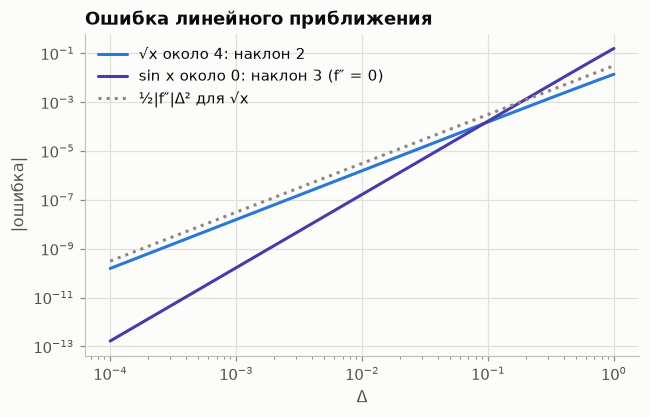

квадрат 10 → 10.1: ΔA = 2.01  dA = 2·s·ds = 2.0


In [9]:
cases = [("√4.1", np.sqrt, 0.25, 4, 0.1), ("sin 0.1", np.sin, 1, 0, 0.1), ("e^0.1", np.exp, 1, 0, 0.1),
         ("ln 1.05", np.log, 1, 1, 0.05), ("∛8.3", np.cbrt, 1 / 12, 8, 0.3), ("1/0.98", lambda x: 1 / x, -1, 1, -0.02),
         ("1.02¹⁰", lambda x: x**10, 10, 1, 0.02)]
for name, g2, d1, a, d in cases:
    approx = g2(a) + d1 * d
    print(f"{name:8}: приближение {approx:.6f}, точно {g2(a + d):.6f}, ошибка {approx - g2(a + d):+.2e}")

ds = np.logspace(-4, 0, 50)
fig, ax = plt.subplots(figsize=(6.5, 3.8))
ax.loglog(ds, np.abs(2 + 0.25 * ds - np.sqrt(4 + ds)), color=BLUE, lw=2, label="√x около 4: наклон 2")
ax.loglog(ds, np.abs(ds - np.sin(ds)), color=VIOLET, lw=2, label="sin x около 0: наклон 3 (f″ = 0)")
ax.loglog(ds, ds**2 / 32, ":", color=MUTED, label="½|f″|Δ² для √x")
ax.set(xlabel="Δ", ylabel="|ошибка|", title="Ошибка линейного приближения")
ax.legend()
plt.show()
print("квадрат 10 → 10.1: ΔA =", round(10.1**2 - 100, 4), " dA = 2·s·ds =", 2 * 10 * 0.1)

## Блок 3. Когда производной нет

### 11–12. Односторонние производные и галерея

Производная есть ⇔ $f'_-(a) = f'_+(a)$. Излом — разные конечные пределы, остриё — $\mp\infty$,
вертикальная касательная — $+\infty$ с обеих сторон, скачок — функция разрывна, колебания — предела нет.

In [10]:
gallery = {
    "|x|": np.abs,
    "√|x|": lambda x: np.sqrt(np.abs(x)),
    "∛x": np.cbrt,
    "[x ≥ 0]": lambda x: (np.asarray(x) >= 0) * 1.0,
    "x·sin(1/x)": lambda x: x * np.sin(1 / x) if x != 0 else 0.0,
    "x²·sin(1/x)": lambda x: x**2 * np.sin(1 / x) if x != 0 else 0.0,
    "склейка x² | 2x − 1 в 1": lambda x: x**2 if x < 1 else 2 * x - 1,
}
for name, g2 in gallery.items():
    a = 1.0 if "склейка" in name else 0.0
    right = [quotient(g2, a, h) for h in (1e-2, 1e-4, 1e-6)]
    left = [quotient(g2, a, -h) for h in (1e-2, 1e-4, 1e-6)]
    print(f"{name:24} справа {np.round(right, 4)}, слева {np.round(left, 4)}")

|x|                      справа [1. 1. 1.], слева [-1. -1. -1.]
√|x|                     справа [  10.  100. 1000.], слева [  -10.  -100. -1000.]
∛x                       справа [   21.5443   464.1589 10000.    ], слева [   21.5443   464.1589 10000.    ]
[x ≥ 0]                  справа [0. 0. 0.], слева [1.e+02 1.e+04 1.e+06]
x·sin(1/x)               справа [-0.5064 -0.3056 -0.35  ], слева [0.5064 0.3056 0.35  ]
x²·sin(1/x)              справа [-0.0051 -0.     -0.    ], слева [-0.0051 -0.     -0.    ]
склейка x² | 2x − 1 в 1  справа [2. 2. 2.], слева [1.99   1.9999 2.    ]


### 13. Гладкость

Дифференцируемая функция непрерывна, обратное неверно. Классы: разрывная (дерево) ⊂ $C^0$ (MAE, ReLU) ⊂ $C^1$ (Хьюбер) ⊂ $C^\infty$
(MSE, log-loss). Рисуем $f$, $f'$, $f''$ для потерь Хьюбера: $f'$ непрерывна, $f''$ прыгает.

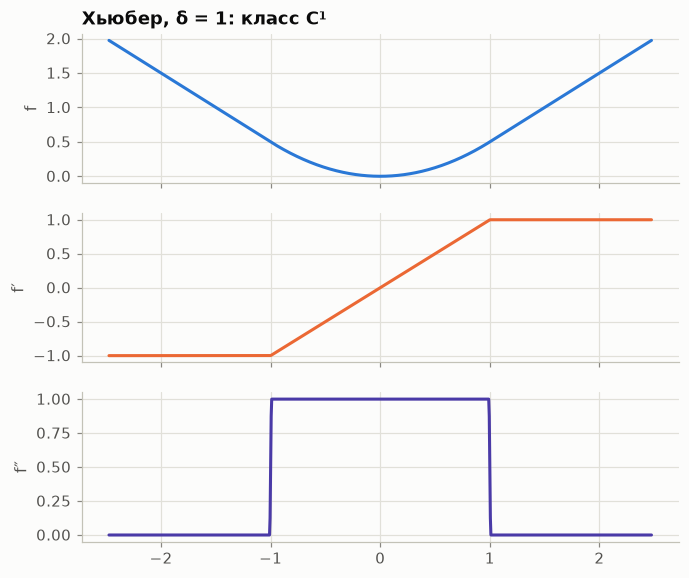

In [11]:
x = np.linspace(-2.5, 2.5, 1001)
hub = np.where(np.abs(x) <= 1, 0.5 * x**2, np.abs(x) - 0.5)
d1 = np.gradient(hub, x)
d2 = np.gradient(d1, x)
fig, axes = plt.subplots(3, 1, figsize=(7, 6), sharex=True)
for ax, v, name, c in zip(axes, [hub, d1, d2], ["f", "f′", "f″"], [BLUE, ORANGE, VIOLET]):
    ax.plot(x[5:-5], v[5:-5], color=c, lw=2)
    ax.set_ylabel(name)
axes[0].set_title("Хьюбер, δ = 1: класс C¹")
plt.show()

### 14. Субградиент

Для выпуклой функции в изломе $\partial f(a) = [f'_-(a); f'_+(a)]$, минимум ⇔ $0 \in \partial f(a)$.
MAE шести квартир: $\partial L(4) = [-\frac13; 0]$ — медиана.

In [12]:
flats = np.array([2, 4, 3, 7, 9, 11], dtype=float)
mae = lambda c: np.mean(np.abs(flats - c))  # noqa: E731
for c in [3.5, 4, 5.5, 7, 8]:
    left = round(quotient(mae, c, -1e-7), 6)
    right = round(quotient(mae, c, 1e-7), 6)
    print(f"c = {c}: ∂L = [{left:+.4f}; {right:+.4f}], минимум: {left <= 0 <= right}")

c = 3.5: ∂L = [-0.3333; -0.3333], минимум: False
c = 4: ∂L = [-0.3333; +0.0000], минимум: True
c = 5.5: ∂L = [-0.0000; +0.0000], минимум: True
c = 7: ∂L = [-0.0000; +0.3333], минимум: True
c = 8: ∂L = [+0.3333; +0.3333], минимум: False


## Блок 4. Что производная говорит о функции

### 15–17. Монотонность, экстремумы, теорема Ферма

$f' > 0$ — растёт; в экстремуме $f' = 0$ или производной нет; на отрезке проверяем и концы.
Сверяем свой алгоритм кандидатов с `scipy.optimize.minimize_scalar`.

In [13]:
def candidates(g2, dg, a, b, kinks=()):
    """Концы, нули f′ (смена знака на сетке + brentq) и изломы внутри [a, b]."""
    x = np.linspace(a, b, 20001)
    d = dg(x)
    roots = [optimize.brentq(dg, x[i], x[i + 1]) for i in np.where(np.sign(d[:-1]) * np.sign(d[1:]) < 0)[0]]
    roots += list(x[1:-1][d[1:-1] == 0])  # корень ровно в узле сетки
    pts = sorted({a, b, *roots, *[k for k in kinks if a < k < b]})
    return np.array(pts), g2(np.array(pts))


problems = [
    ("x² − 4x на [0, 5]", lambda x: x**2 - 4 * x, lambda x: 2 * x - 4, 0, 5, ()),
    ("x³ − 3x на [−2, 3]", lambda x: x**3 - 3 * x, lambda x: 3 * x**2 - 3, -2, 3, ()),
    ("x·e⁻ˣ на [0, 4]", lambda x: x * np.exp(-x), lambda x: (1 - x) * np.exp(-x), 0, 4, ()),
    ("x⁴ − 2x² на [−1.5, 2]", lambda x: x**4 - 2 * x**2, lambda x: 4 * x**3 - 4 * x, -1.5, 2, ()),
    ("|x² − 1| на [−2, 2]", lambda x: np.abs(x**2 - 1), lambda x: 2 * x * np.sign(x**2 - 1), -2, 2, (-1, 1)),
    ("площадь x(10 − x) на [0, 10]", lambda x: x * (10 - x), lambda x: 10 - 2 * x, 0, 10, ()),
]
for name, g2, dg, a, b, kinks in problems:
    pts, vals = candidates(g2, dg, a, b, kinks)
    res = optimize.minimize_scalar(g2, bounds=(a, b), method="bounded")
    print(f"{name:30} max {vals.max():.4f} при x = {pts[vals.argmax()]:.4f}; min {vals.min():.4f} при x = {pts[vals.argmin()]:.4f}"
          f"   (scipy, локальный поиск: {res.fun:.4f})")

x² − 4x на [0, 5]              max 5.0000 при x = 5.0000; min -4.0000 при x = 2.0000   (scipy, локальный поиск: -4.0000)
x³ − 3x на [−2, 3]             max 18.0000 при x = 3.0000; min -2.0000 при x = -2.0000   (scipy, локальный поиск: -2.0000)
x·e⁻ˣ на [0, 4]                max 0.3679 при x = 1.0000; min 0.0000 при x = 0.0000   (scipy, локальный поиск: 0.0733)
x⁴ − 2x² на [−1.5, 2]          max 8.0000 при x = 2.0000; min -1.0000 при x = -1.0000   (scipy, локальный поиск: -1.0000)
|x² − 1| на [−2, 2]            max 3.0000 при x = -2.0000; min 0.0000 при x = -1.0000   (scipy, локальный поиск: 0.0000)
площадь x(10 − x) на [0, 10]   max 25.0000 при x = 5.0000; min 0.0000 при x = 0.0000   (scipy, локальный поиск: 0.0001)


### 18. Теоремы Ролля и Лагранжа

Найдётся $c$, где касательная параллельна секущей: $f'(c) = \frac{f(b) - f(a)}{b - a}$. Следствия: монотонность,
постоянство, оценка $|f(b) - f(a)| \le M|b - a|$ (для сигмоиды $M = \frac14$).

In [14]:
for name, g2, dg, a, b in [("x³ на [0, 2]", lambda x: x**3, lambda x: 3 * x**2, 0, 2),
                            ("sin на [0, π/2]", np.sin, np.cos, 0, np.pi / 2),
                            ("√x на [0, 4]", np.sqrt, lambda x: 0.5 / np.sqrt(x), 0, 4)]:
    k = (g2(b) - g2(a)) / (b - a)
    c = optimize.brentq(lambda t, dg=dg, k=k: dg(t) - k, a + 1e-9, b - 1e-9)
    print(f"{name:16}: наклон секущей {k:.4f}, c = {c:.4f}, f′(c) = {dg(c):.4f}")

sig = lambda z: 1 / (1 + np.exp(-z))  # noqa: E731
z = np.linspace(-8, 8, 2001)
print("max σ′ =", np.max(central(sig, z)), "→ |σ(a) − σ(b)| ≤ |a − b| / 4")
print("√101 − 10 =", np.sqrt(101) - 10, "между", 1 / (2 * np.sqrt(101)), "и", 0.05)

x³ на [0, 2]    : наклон секущей 4.0000, c = 1.1547, f′(c) = 4.0000
sin на [0, π/2] : наклон секущей 0.6366, c = 0.8807, f′(c) = 0.6366
√x на [0, 4]    : наклон секущей 0.5000, c = 1.0000, f′(c) = 0.5000
max σ′ = 0.2499999999933111 → |σ(a) − σ(b)| ≤ |a − b| / 4
√101 − 10 = 0.049875621120889946 между 0.04975185951049946 и 0.05


## Блок 5. Как считать

### 19–20. Линейность и обратная функция

$(\alpha f + \beta g)' = \alpha f' + \beta g'$; $(f^{-1})'(y) = 1/f'(x)$. Отсюда $(\ln y)' = 1/y$ и $\operatorname{logit}'(p) = \frac{1}{p(1 - p)}$.

In [15]:
hmix = lambda x: 2 * np.exp(x) - 3 * np.sin(x) + np.sqrt(x)  # noqa: E731
x0 = 0.7
print("линейность:", central(hmix, x0), "≈", 2 * np.exp(x0) - 3 * np.cos(x0) + 1 / (2 * np.sqrt(x0)))
logit = lambda p: np.log(p / (1 - p))  # noqa: E731
for p in [0.5, 0.9, 0.99]:
    print(f"logit′({p}) численно {central(logit, p, 1e-7):.4f}, по формуле 1/(p(1 − p)) = {1 / (p * (1 - p)):.4f}")
print("(ln y)′ в y = 3:", central(np.log, 3.0), "≈ 1/3")

линейность: 2.3305931578843087 ≈ 2.330593157754685
logit′(0.5) численно 4.0000, по формуле 1/(p(1 − p)) = 4.0000
logit′(0.9) численно 11.1111, по формуле 1/(p(1 − p)) = 11.1111
logit′(0.99) численно 101.0101, по формуле 1/(p(1 − p)) = 101.0101
(ln y)′ в y = 3: 0.33333333333551707 ≈ 1/3


### 21. Численная производная: усечение против округления

Вперёд — ошибка ~$h$, центральная — ~$h^2$, округление — ~$10^{-16}/h$. Для $\sin$ в точке 1 лучший шаг $10^{-8}$ (вперёд)
и $10^{-5}$ (центральная); Ричардсон $\frac{4D(h/2) - D(h)}{3}$ ещё точнее. Сверка: `scipy.optimize.approx_fprime`
(разность вперёд с шагом $\sqrt{\varepsilon}$).

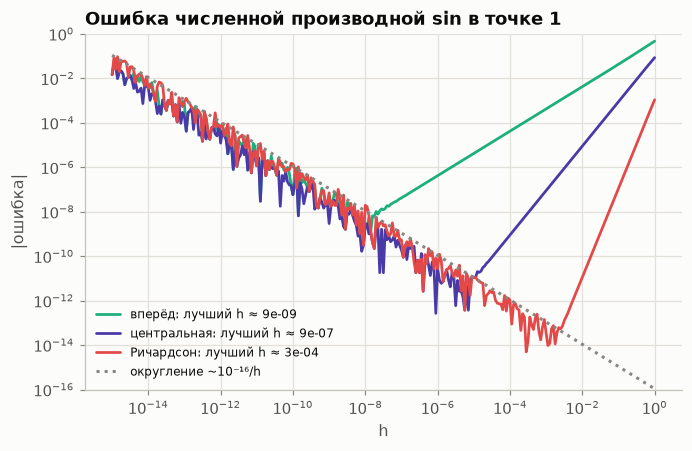

x³ в 1, h = 0.1: вперёд 3.310000000000004 центральная 3.0100000000000016
scipy approx_fprime: 0.5403022989630699 точно 0.5403023058681398


In [16]:
hs = np.logspace(-15, 0, 301)
exact = np.cos(1.0)
fwd = np.abs((np.sin(1 + hs) - np.sin(1)) / hs - exact)
cen = np.abs((np.sin(1 + hs) - np.sin(1 - hs)) / (2 * hs) - exact)
D = lambda t: (np.sin(1 + t) - np.sin(1 - t)) / (2 * t)  # noqa: E731
rich = np.abs((4 * D(hs / 2) - D(hs)) / 3 - exact)
fig, ax = plt.subplots(figsize=(7, 4.2))
for err, name, c in [(fwd, "вперёд", AQUA), (cen, "центральная", VIOLET), (rich, "Ричардсон", RED)]:
    ax.loglog(hs, np.where(err > 0, err, np.nan), color=c, lw=1.8, label=f"{name}: лучший h ≈ {hs[np.nanargmin(np.where(err > 0, err, np.nan))]:.0e}")
ax.loglog(hs, 1.1e-16 / hs, ":", color=MUTED, label="округление ~10⁻¹⁶/h")
ax.set(xlabel="h", ylabel="|ошибка|", ylim=(1e-16, 1), title="Ошибка численной производной sin в точке 1")
ax.legend(fontsize=8)
plt.show()
print("x³ в 1, h = 0.1: вперёд", quotient(lambda x: x**3, 1, 0.1), "центральная", central(lambda x: x**3, 1, 0.1))
print("scipy approx_fprime:", optimize.approx_fprime(np.array([1.0]), lambda v: np.sin(v[0]))[0], "точно", exact)

### 22. Производная по шумным данным

Шум $\sigma$ превращается в ошибку производной ~$\sigma/(\sqrt2 h)$, усечение — ~$h^2/6$. Данные те же, что в виджете:
$\sin x$ с шагом 0.01 и шумом от `Mulberry32(7)`.

σ = 0.001: RMSE при h = 0.01 — 0.0710, лучший h = 0.20 — RMSE 0.0057
σ = 0.01: RMSE при h = 0.01 — 0.7096, лучший h = 0.40 — RMSE 0.0247
σ = 0.05: RMSE при h = 0.01 — 3.5478, лучший h = 0.80 — RMSE 0.0779


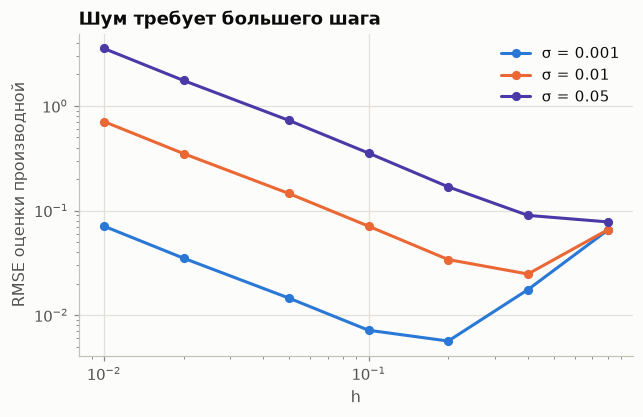

In [17]:
rng = Mulberry32(7)
x = np.arange(629) * 0.01
noise = np.array([rng.normal() for _ in x])
ks = [1, 2, 5, 10, 20, 40, 80]
fig, ax = plt.subplots(figsize=(6.5, 3.8))
for sigma, c in [(1e-3, BLUE), (1e-2, ORANGE), (0.05, VIOLET)]:
    y = np.sin(x) + sigma * noise
    rmse = [np.sqrt(np.mean(((y[2 * k:] - y[:-2 * k]) / (2 * k * 0.01) - np.cos(x[k:-k])) ** 2)) for k in ks]
    best = ks[int(np.argmin(rmse))] * 0.01
    print(f"σ = {sigma}: RMSE при h = 0.01 — {rmse[0]:.4f}, лучший h = {best:.2f} — RMSE {min(rmse):.4f}")
    ax.loglog(np.array(ks) * 0.01, rmse, "o-", color=c, label=f"σ = {sigma}")
ax.set(xlabel="h", ylabel="RMSE оценки производной", title="Шум требует большего шага")
ax.legend()
plt.show()

## Блок 6. Производная в машинном обучении

### 23. Градиентный спуск и темп

На $f = \frac a2\theta^2$ шаг умножает $\theta$ на $q = 1 - \eta a$: сходимость при $0 < \eta < 2/a$, за один шаг при $\eta = 1/a$.

In [18]:
for eta in [0.3, 0.5, 0.75, 1.0, 1.1]:
    t, path = 2.0, [2.0]
    for _ in range(6):
        t -= eta * 2 * t
        path.append(t)
    print(f"a = 2, η = {eta}: q = {1 - 2 * eta:+.2f}  θ: {np.round(path, 4)}")

a = 2, η = 0.3: q = +0.40  θ: [2.     0.8    0.32   0.128  0.0512 0.0205 0.0082]
a = 2, η = 0.5: q = +0.00  θ: [2. 0. 0. 0. 0. 0. 0.]
a = 2, η = 0.75: q = -0.50  θ: [ 2.     -1.      0.5    -0.25    0.125  -0.0625  0.0312]
a = 2, η = 1.0: q = -1.00  θ: [ 2. -2.  2. -2.  2. -2.  2.]
a = 2, η = 1.1: q = -1.20  θ: [ 2.     -2.4     2.88   -3.456   4.1472 -4.9766  5.972 ]


### 24–25. Производные потерь и лучшая константа

Псевдо-остаток $-\partial L/\partial F$: $y - F$ (MSE), $\operatorname{sign}(y - F)$ (MAE), $\operatorname{clip}(y - F, -\delta, \delta)$ (Хьюбер),
$\alpha$ или $\alpha - 1$ (квантильные), $y - \sigma(F)$ (log-loss). Проверяем формулы центральной разностью и находим лучшие
константы для шести квартир.

In [19]:
losses = {
    "MSE": (lambda y, F: 0.5 * (y - F) ** 2, lambda y, F: -(y - F)),
    "MAE": (lambda y, F: np.abs(y - F), lambda y, F: -np.sign(y - F)),
    "Хьюбер δ=1": (lambda y, F: np.where(np.abs(y - F) <= 1, 0.5 * (y - F) ** 2, np.abs(y - F) - 0.5), lambda y, F: -np.clip(y - F, -1, 1)),
    "квантиль α=0.8": (lambda y, F: np.where(y >= F, 0.8 * (y - F), -0.2 * (y - F)), lambda y, F: np.where(y > F, -0.8, 0.2)),
    "log-loss": (lambda y, F: np.logaddexp(0, F) - y * F, lambda y, F: sig(F) - y),
}
for name, (Lf, gf) in losses.items():
    yv, Fv = (1.0, 0.0) if name == "log-loss" else (5.0, 2.0)
    num = central(lambda F, Lf=Lf, yv=yv: Lf(yv, F), Fv)
    print(f"{name:15} y = {yv}, F = {Fv}: ∂L/∂F формула {float(gf(yv, Fv)):+.4f}, численно {num:+.4f}, псевдо-остаток {-float(gf(yv, Fv)):+.4f}")

cs = np.linspace(0, 12, 120001)
for name, Lc in [("MSE", lambda c: np.mean(0.5 * (flats[:, None] - c) ** 2, axis=0)),
                 ("MAE", lambda c: np.mean(np.abs(flats[:, None] - c), axis=0)),
                 ("Хьюбер δ=2", lambda c: np.mean(np.where(np.abs(flats[:, None] - c) <= 2, 0.5 * (flats[:, None] - c) ** 2, 2 * (np.abs(flats[:, None] - c) - 1)), axis=0))]:
    vals = Lc(cs)
    best = cs[np.isclose(vals, vals.min(), rtol=0, atol=1e-9)]
    print(f"{name:11}: лучшая константа {best.min():.3f} … {best.max():.3f}")

c = 3.0
for k in range(5):
    c -= 0.5 * np.mean(c - flats)
    print(f"спуск по MSE, шаг {k + 1}: c = {c}")

MSE             y = 5.0, F = 2.0: ∂L/∂F формула -3.0000, численно -3.0000, псевдо-остаток +3.0000
MAE             y = 5.0, F = 2.0: ∂L/∂F формула -1.0000, численно -1.0000, псевдо-остаток +1.0000
Хьюбер δ=1      y = 5.0, F = 2.0: ∂L/∂F формула -1.0000, численно -1.0000, псевдо-остаток +1.0000
квантиль α=0.8  y = 5.0, F = 2.0: ∂L/∂F формула -0.8000, численно -0.8000, псевдо-остаток +0.8000
log-loss        y = 1.0, F = 0.0: ∂L/∂F формула -0.5000, численно -0.5000, псевдо-остаток +0.5000
MSE        : лучшая константа 6.000 … 6.000
MAE        : лучшая константа 4.000 … 7.000
Хьюбер δ=2 : лучшая константа 5.500 … 5.500
спуск по MSE, шаг 1: c = 4.5
спуск по MSE, шаг 2: c = 5.25
спуск по MSE, шаг 3: c = 5.625
спуск по MSE, шаг 4: c = 5.8125
спуск по MSE, шаг 5: c = 5.90625


### 26. Псевдо-остатки и пень

Шаг бустинга: $r_i = -\partial L/\partial F_i$ → пень учится их предсказывать → $F \leftarrow F + \nu\,h(x)$.
Сверяем с `sklearn.ensemble.GradientBoostingRegressor` (первое дерево обучается на тех же остатках).

In [20]:
from sklearn.ensemble import GradientBoostingRegressor

X = np.arange(1, 7, dtype=float).reshape(-1, 1)
F = np.full(6, flats.mean())
for m in range(3):
    r = flats - F
    stump = RegressionTree(max_depth=1).fit(X, -r)
    F = F + 0.5 * stump.predict(X)
    print(f"дерево {m + 1}: r = {r}, F = {np.round(F, 4)}, потери {np.mean(0.5 * (flats - F) ** 2):.4f}")

sk = GradientBoostingRegressor(n_estimators=1, learning_rate=0.5, max_depth=1).fit(X, flats)
gb = GBRegressor(n_estimators=1, learning_rate=0.5, max_depth=1).fit(X, flats)
print("sklearn после 1 дерева:", sk.predict(X))
print("gbcourse после 1 дерева:", gb.predict(X))
assert np.allclose(sk.predict(X), gb.predict(X))

дерево 1: r = [-4. -2. -3.  1.  3.  5.], F = [4.5 4.5 4.5 7.5 7.5 7.5], потери 1.9583
дерево 2: r = [-2.5 -0.5 -1.5 -0.5  1.5  3.5], F = [3.875 3.875 3.875 6.875 8.75  8.75 ], потери 0.7865
дерево 3: r = [-1.875  0.125 -0.875  0.125  0.25   2.25 ], F = [3.65  3.65  3.65  6.65  8.525 9.875], потери 0.4068
sklearn после 1 дерева: [4.5 4.5 4.5 7.5 7.5 7.5]
gbcourse после 1 дерева: [4.5 4.5 4.5 7.5 7.5 7.5]


### 27. Наклон прогноза бустинга по признаку

Прогноз — лестница: при малом $h$ разностное отношение почти везде 0, на порогах — огромное. Поэтому бустинг
дифференцирует потери по прогнозу, а наклон модели по признаку меряют только с крупным шагом.

h = 0.001: нулевых 99.1%, RMSE против cos x 18.593
h = 1.0: нулевых 0.0%, RMSE против cos x 0.253


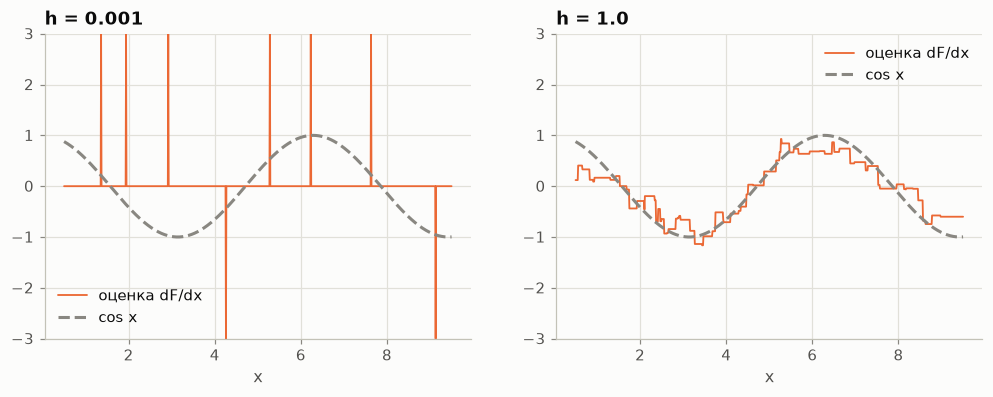

In [21]:
Xs, ys = datasets.regression_1d(kind="sine", n=60, noise=0.3, seed=7)
model = GBRegressor(n_estimators=60, learning_rate=0.2, max_depth=2).fit(Xs, ys)
grid = np.linspace(0.5, 9.5, 901)
Fm = lambda v: model.predict(v.reshape(-1, 1))  # noqa: E731
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, h in zip(axes, [1e-3, 1.0]):
    est = (Fm(grid + h) - Fm(grid - h)) / (2 * h)
    print(f"h = {h}: нулевых {np.mean(np.abs(est) < 1e-12):.1%}, RMSE против cos x {np.sqrt(np.mean((est - np.cos(grid)) ** 2)):.3f}")
    ax.plot(grid, np.clip(est, -3, 3), color=ORANGE, lw=1.2, label="оценка dF/dx")
    ax.plot(grid, np.cos(grid), "--", color=MUTED, label="cos x")
    ax.set(title=f"h = {h}", xlabel="x", ylim=(-3, 3))
    ax.legend()
plt.show()

## Упражнения

Задания — `lessons/lesson_15_5/exercises/tasks.md`, решения — `exercises/solutions.py`. Попробуйте:

1. Найти по определению производные $5x^2 - 3$ и $\frac{1}{x + 1}$ и проверить их функцией `quotient`.
2. Составить касательные к $e^x$ в точках −1, 0, 1 и убедиться, что все лежат под графиком.
3. Найти наибольшее значение $x^2 e^{-x}$ на $[0; 5]$ функцией `candidates`.
4. Повторить опыт блока 22 со своей функцией и шумом и найти лучший шаг.